# Сегментация пользователей User_Data_Dataset

**Задача:** Сегментация пользователей по географии, устройствам, ОС и источникам трафика с расчетом ключевых метрик и визуализацией.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import plotly.express as px
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.express as px

## 2. Загрузка и предобработка данных

In [2]:
import pandas as pd

df = pd.read_csv("User_Data_Dataset.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   UserID         200 non-null    int64  
 1   Country        200 non-null    object 
 2   City           200 non-null    object 
 3   DeviceType     200 non-null    object 
 4   OS             200 non-null    object 
 5   TrafficSource  200 non-null    object 
 6   TimeOnSite     200 non-null    float64
 7   PagesViewed    200 non-null    int64  
 8   ItemsInCart    200 non-null    int64  
 9   Purchases      200 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 15.8+ KB


,UserID,TimeOnSite,PagesViewed,ItemsInCart,Purchases
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,11.541700,5.600000,2.620000,1.450000
std,57.879185,5.079355,2.926229,1.828199,1.552272
min,1.000000,3.020000,1.000000,0.000000,0.000000
25%,50.750000,7.182500,3.000000,1.000000,0.000000
50%,100.500000,11.460000,6.000000,3.000000,1.000000
75%,150.250000,16.395000,8.000000,4.000000,3.000000
max,200.000000,19.990000,10.000000,5.000000,5.000000


Датасет небольшой и подходит для учебного анализа сегментации: содержит пользовательские данные по географии, устройствам, ОС и источникам трафика с метриками вовлеченности и покупок.

In [3]:
# Проверка пропусков
df.isna().sum()

UserID           0
Country          0
City             0
DeviceType       0
OS               0
TrafficSource    0
TimeOnSite       0
PagesViewed      0
ItemsInCart      0
Purchases        0
dtype: int64

In [4]:
# Убеждаемся, что числовые колонки имеют правильный тип
numeric_cols = ["TimeOnSite", "PagesViewed", "ItemsInCart", "Purchases"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# При необходимости заполняем пропуски (медианой по колонке)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   UserID         200 non-null    int64  
 1   Country        200 non-null    object 
 2   City           200 non-null    object 
 3   DeviceType     200 non-null    object 
 4   OS             200 non-null    object 
 5   TrafficSource  200 non-null    object 
 6   TimeOnSite     200 non-null    float64
 7   PagesViewed    200 non-null    int64  
 8   ItemsInCart    200 non-null    int64  
 9   Purchases      200 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 15.8+ KB


## 3. Функция для расчёта конверсии

In [5]:
def add_conversion(df_grouped, purchases_col="Purchases", cart_col="ItemsInCart"):
    df_grouped = df_grouped.copy()
    df_grouped["Conversion"] = df_grouped.apply(
        lambda row: row[purchases_col] / row[cart_col] if row[cart_col] > 0 else 0,
        axis=1
    )
    return df_grouped

## 4. Сегментация и метрики

### 4.1. География (Country и Country–City)

In [6]:
geo_country_stats = df.groupby("Country").agg(
    TimeOnSite_mean=("TimeOnSite", "mean"),
    PagesViewed_mean=("PagesViewed", "mean"),
    Purchases_sum=("Purchases", "sum"),
    ItemsInCart_sum=("ItemsInCart", "sum"),
).reset_index()
geo_country_stats = add_conversion(geo_country_stats, purchases_col="Purchases_sum", cart_col="ItemsInCart_sum")
geo_country_stats

,Country,TimeOnSite_mean,PagesViewed_mean,Purchases_sum,ItemsInCart_sum,Conversion
0,Canada,12.486061,5.484848,44,88,0.500000
1,France,11.585682,4.977273,53,107,0.495327
2,Germany,11.178621,5.620690,36,64,0.562500
3,India,9.898667,6.166667,63,91,0.692308
4,UK,12.100278,5.638889,51,102,0.500000
5,USA,11.777857,6.035714,43,72,0.597222


In [7]:
geo_city_stats = df.groupby(["Country", "City"]).agg(
    TimeOnSite_mean=("TimeOnSite", "mean"),
    PagesViewed_mean=("PagesViewed", "mean"),
    Purchases_sum=("Purchases", "sum"),
    ItemsInCart_sum=("ItemsInCart", "sum"),
).reset_index()
geo_city_stats = add_conversion(geo_city_stats, purchases_col="Purchases_sum", cart_col="ItemsInCart_sum")
geo_city_stats

,Country,City,TimeOnSite_mean,PagesViewed_mean,Purchases_sum,ItemsInCart_sum,Conversion
0,Canada,Montreal,9.465000,6.833333,6,23,0.260870
1,Canada,Toronto,13.976667,5.466667,23,43,0.534884
2,Canada,Vancouver,14.801667,2.833333,15,22,0.681818
3,France,Lyon,8.420000,4.545455,18,29,0.620690
4,France,Marseille,12.440000,5.200000,20,51,0.392157
5,France,Paris,12.950000,5.000000,15,27,0.555556
6,Germany,Berlin,9.282857,6.000000,15,21,0.714286
7,Germany,Frankfurt,12.035000,6.375000,8,14,0.571429
8,Germany,Munich,11.637143,5.000000,13,29,0.448276
9,India,Bangalore,9.953333,5.833333,24,36,0.666667


### 4.2. Тип устройства (DeviceType)

In [8]:
device_stats = df.groupby("DeviceType").agg(
    TimeOnSite_mean=("TimeOnSite", "mean"),
    PagesViewed_mean=("PagesViewed", "mean"),
    Purchases_sum=("Purchases", "sum"),
    ItemsInCart_sum=("ItemsInCart", "sum"),
).reset_index()
device_stats = add_conversion(device_stats, purchases_col="Purchases_sum", cart_col="ItemsInCart_sum")
device_stats

,DeviceType,TimeOnSite_mean,PagesViewed_mean,Purchases_sum,ItemsInCart_sum,Conversion
0,Desktop,11.730889,5.866667,39,94,0.414894
1,Laptop,12.238596,5.350877,102,158,0.645570
2,Smartphone,10.776731,5.961538,87,143,0.608392
3,Tablet,11.357826,5.239130,62,129,0.480620


### 4.3. Операционная система (OS)

In [9]:
os_stats = df.groupby("OS").agg(
    TimeOnSite_mean=("TimeOnSite", "mean"),
    PagesViewed_mean=("PagesViewed", "mean"),
    Purchases_sum=("Purchases", "sum"),
    ItemsInCart_sum=("ItemsInCart", "sum"),
).reset_index()
os_stats = add_conversion(os_stats, purchases_col="Purchases_sum", cart_col="ItemsInCart_sum")
os_stats

,OS,TimeOnSite_mean,PagesViewed_mean,Purchases_sum,ItemsInCart_sum,Conversion
0,Android,12.160862,5.241379,79,176,0.448864
1,Windows,11.599245,5.886792,83,122,0.680328
2,iOS,11.948679,5.811321,64,128,0.500000
3,macOS,9.860278,5.444444,64,98,0.653061


### 4.4. Источники трафика (TrafficSource)

In [10]:
traffic_stats = df.groupby("TrafficSource").agg(
    TimeOnSite_mean=("TimeOnSite", "mean"),
    PagesViewed_mean=("PagesViewed", "mean"),
    Purchases_sum=("Purchases", "sum"),
    ItemsInCart_sum=("ItemsInCart", "sum"),
).reset_index()
traffic_stats = add_conversion(traffic_stats, purchases_col="Purchases_sum", cart_col="ItemsInCart_sum")
traffic_stats

,TrafficSource,TimeOnSite_mean,PagesViewed_mean,Purchases_sum,ItemsInCart_sum,Conversion
0,Direct,10.787538,6.015385,79,140,0.564286
1,Referrals,11.943556,5.422222,61,130,0.469231
2,Search Engines,11.598000,5.000000,88,139,0.633094
3,Social Networks,12.244750,5.875000,62,115,0.539130


**Комментарий по источникам трафика:** Сравните столбцы Conversion, TimeOnSite_mean и PagesViewed_mean: у каких источников выше конверсия, где больше вовлеченность (время на сайте и число просмотренных страниц). Обычно Direct и Search Engines дают более целевой трафик; Social Networks — выше вовлеченность по страницам.

## 5. Визуализация результатов сегментации

### География

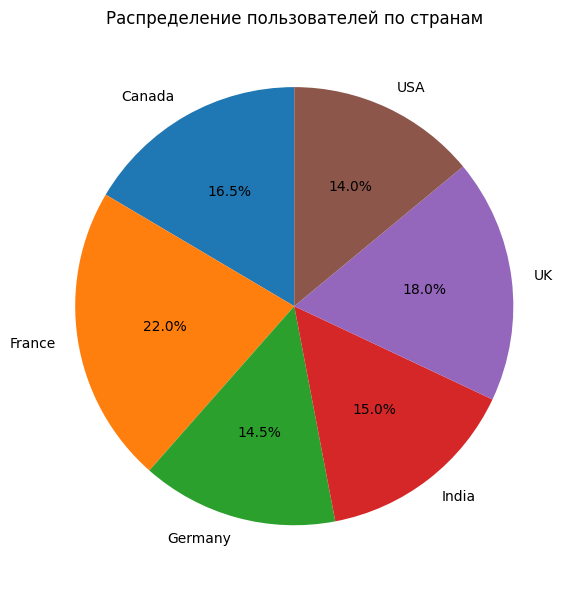

In [11]:
users_by_country = df.groupby("Country").size().reset_index(name="Users")
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(users_by_country["Users"], labels=users_by_country["Country"], autopct="%1.1f%%", startangle=90)
ax.set_title("Распределение пользователей по странам")
plt.tight_layout()
plt.show()

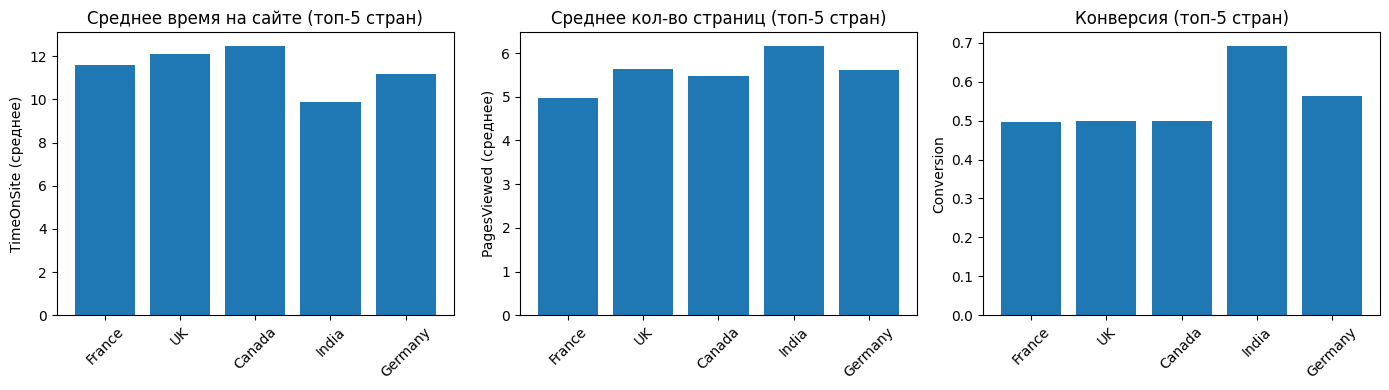

In [12]:
# Топ-5 стран по числу пользователей
top5_countries = df.groupby("Country").size().nlargest(5).index.tolist()
top5 = geo_country_stats[geo_country_stats["Country"].isin(top5_countries)]
# Сохраняем порядок топ-5 по убыванию числа пользователей
top5 = top5.set_index("Country").loc[top5_countries].reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(top5["Country"], top5["TimeOnSite_mean"])
axes[0].set_title("Среднее время на сайте (топ-5 стран)")
axes[0].set_ylabel("TimeOnSite (среднее)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(top5["Country"], top5["PagesViewed_mean"])
axes[1].set_title("Среднее кол-во страниц (топ-5 стран)")
axes[1].set_ylabel("PagesViewed (среднее)")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(top5["Country"], top5["Conversion"])
axes[2].set_title("Конверсия (топ-5 стран)")
axes[2].set_ylabel("Conversion")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Тип устройства

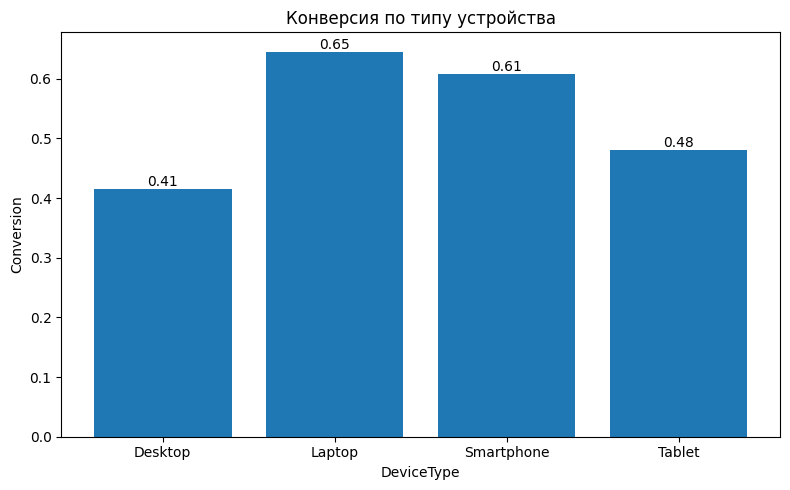

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(device_stats["DeviceType"], device_stats["Conversion"])
ax.set_title("Конверсия по типу устройства")
ax.set_xlabel("DeviceType")
ax.set_ylabel("Conversion")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Операционная система

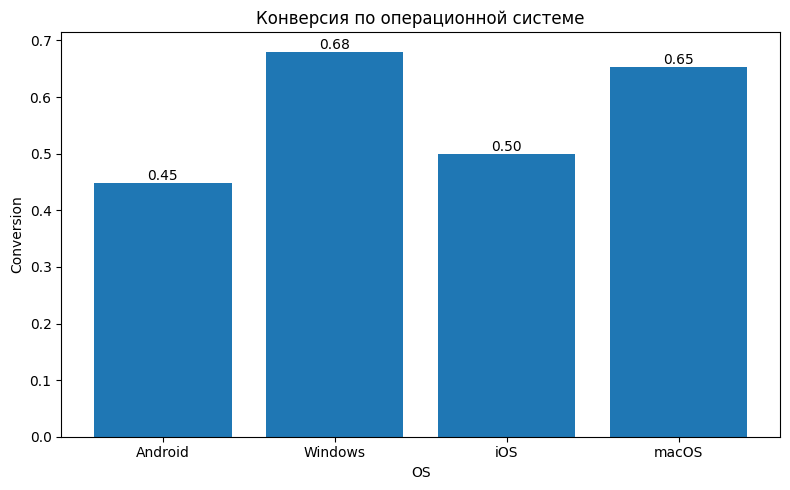

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(os_stats["OS"], os_stats["Conversion"])
ax.set_title("Конверсия по операционной системе")
ax.set_xlabel("OS")
ax.set_ylabel("Conversion")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Источники трафика

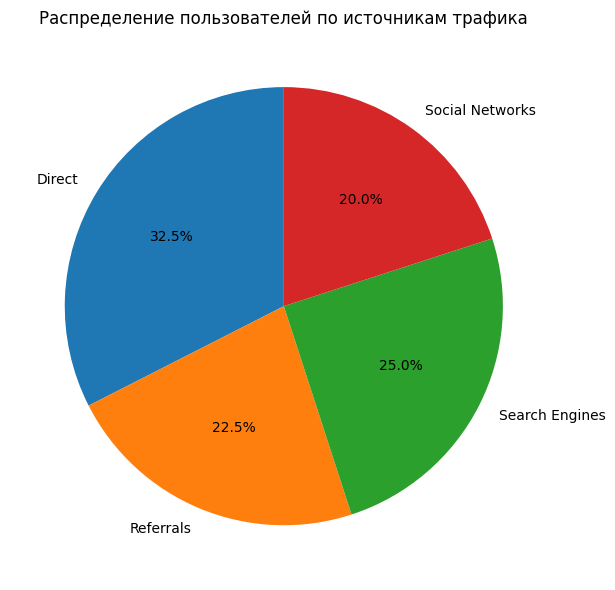

In [15]:
users_by_traffic = df.groupby("TrafficSource").size().reset_index(name="Users")
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(users_by_traffic["Users"], labels=users_by_traffic["TrafficSource"], autopct="%1.1f%%", startangle=90)
ax.set_title("Распределение пользователей по источникам трафика")
plt.tight_layout()
plt.show()

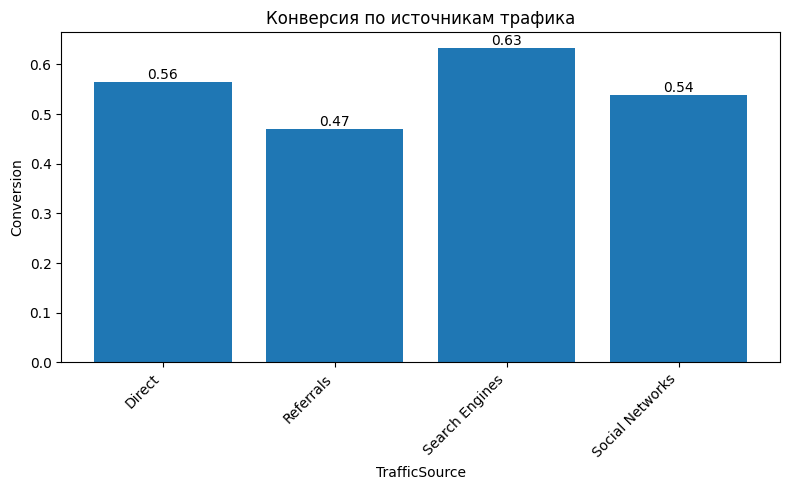

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(traffic_stats["TrafficSource"], traffic_stats["Conversion"])
ax.set_title("Конверсия по источникам трафика")
ax.set_xlabel("TrafficSource")
ax.set_ylabel("Conversion")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", ha="center", va="bottom")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 6. Краткий отчёт по сегментации User_Data_Dataset

**Признаки сегментации:** Country, City (Country–City), DeviceType, OS, TrafficSource.

**Метрики:** среднее время на сайте (mean TimeOnSite), среднее количество просмотренных страниц (mean PagesViewed), сумма покупок (sum Purchases), сумма добавлений в корзину (sum ItemsInCart), конверсия (Conversion = Purchases / ItemsInCart при ItemsInCart > 0).

**Выводы:**
- По географии — страны и города с наибольшей конверсией и вовлеченностью можно считать приоритетными для рекламы и контента.
- По устройствам — тип устройства (Desktop, Laptop, Smartphone, Tablet) влияет на конверсию; обычно десктоп/ноутбук дают более высокую конверсию.
- По ОС — сегменты Windows, macOS, iOS, Android показывают разную конверсию; наиболее перспективные ОС стоит учитывать при таргетинге.
- По источникам трафика — Direct и поисковики часто дают более высокую конверсию; соцсети — выше вовлеченность (время на сайте, страницы). Наиболее перспективными считаются сегменты с высокой конверсией и стабильной вовлеченностью.